<a href="https://colab.research.google.com/github/TKozah/bone-fracture-computer-vision-project/blob/main/v4_notebookD_yolov8_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦴 Bone Fracture AI Pipeline — Notebook D: YOLOv8 Fracture Detection
### Computer Vision Final Project · Saint Joseph University · Spring 2026
### Project Version: CV_project_v4 — Stage 2: Detection

---

## Prerequisites
Run **Notebook A** before this. Loads `dataset_config.json`.  
Notebook B and C (EfficientNet) are independent — run them in parallel if needed.

---

## What this notebook trains

**Stage 2 of the pipeline: YOLOv8 fracture detector**

Input: X-ray image  
Output: Bounding box(es) around fracture location(s) + confidence score

This model runs AFTER EfficientNet says "fractured."  
It answers: **WHERE exactly is the fracture on this bone?**

### Why YOLOv8?
- State-of-the-art real-time object detection (2023)
- Built-in transfer learning from COCO pretrained weights
- Handles variable image sizes natively
- Excellent small-object detection (fracture lines are often thin and small)
- mAP@50 metric is the standard for medical detection benchmarks

### What we train
- **Model:** YOLOv8s (small) — best accuracy/speed trade-off for medical imaging
- **Classes:** 1 (`fracture`)
- **Input:** fractured X-rays with YOLO format bounding box annotations
- **Pretrained:** COCO weights (transfer learning)

---

## Sections

| Section | Content |
|---|---|
| 1 | Install YOLOv8 & imports |
| 2 | Mount Drive & load config |
| 3 | Verify detection dataset |
| 4 | Visualize ground truth bounding boxes |
| 5 | Configure YOLOv8 training |
| 6 | Train YOLOv8 |
| 7 | Evaluate on validation set (mAP, precision, recall) |
| 8 | Visualize detections on validation images |
| 9 | Precision-Recall curve |
| 10 | Save model path to config |
| 11 | Final summary |

---
## 📦 Section 1 — Install YOLOv8 & Imports

YOLOv8 is provided by the `ultralytics` library — one pip install handles everything.

In [ ]:
!pip install -q ultralytics matplotlib pandas numpy seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00


In [ ]:
import os, json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Ultralytics YOLOv8 loaded')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLOv8 loaded
✅ Device: cuda
   GPU: Tesla T4


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print('✅ Truncated image tolerance enabled')

✅ Truncated image tolerance enabled


---
## ⚙️ Section 2 — Mount Drive & Load Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


In [ ]:
CONFIG_PATH = Path('/content/drive/MyDrive/CV_project_v4/dataset_config.json')
if not CONFIG_PATH.exists():
    raise FileNotFoundError('dataset_config.json not found. Run Notebook A first.')

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

PROJECT_ROOT  = Path(cfg['project_root'])
DET_ROOT      = Path(cfg['det_root'])
OUTPUT_DIR    = Path(cfg['output_dir'])
YOLO_YAML     = Path(cfg['det_yaml'])

# YOLOv8 output directory
YOLO_OUT_DIR  = PROJECT_ROOT / 'outputs' / 'yolov8'
YOLO_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════
#  ★  YOLO TRAINING CONFIGURATION
# ════════════════════════════════════════════════════════════════
YOLO_MODEL    = 'yolov8m.pt'   # small model — best for medical imaging
EPOCHS        = 150
IMG_SIZE      = 800           # YOLOv8 standard — larger than EfficientNet but necessary
BATCH         = 16             # reduce to 8 if GPU OOM
PATIENCE      = 20
CONF_THRESH   = 0.25           # confidence threshold for predictions
IOU_THRESH    = 0.45           # IoU threshold for NMS
# ════════════════════════════════════════════════════════════════

print('✅ Config loaded')
print(f'   Detection dataset: {DET_ROOT}')
print(f'   YOLO yaml:         {YOLO_YAML}')
print(f'   Model:             {YOLO_MODEL}')
print(f'   Epochs:            {EPOCHS}')
print(f'   Image size:        {IMG_SIZE}')

✅ Config loaded
   Detection dataset: /content/drive/MyDrive/CV_project_v4/detection_dataset
   YOLO yaml:         /content/drive/MyDrive/CV_project_v4/detection_dataset/data.yaml
   Model:             yolov8m.pt
   Epochs:            150
   Image size:        800


---
## 🔍 Section 3 — Verify Detection Dataset

Verifies the YOLO-format dataset built by Notebook A is correct.
Shows counts of positive (fractured) vs negative (empty label) images per split.

In [ ]:
print('Detection dataset verification:')
print(f'{"Split":<8} {"Images":>8} {"Fractured":>11} {"Normal":>8} {"Labels match":>14}')
print('─'*50)

for split in ['train','val','test']:
    img_dir = DET_ROOT / split / 'images'
    lbl_dir = DET_ROOT / split / 'labels'
    if not img_dir.exists(): continue

    images  = list(img_dir.glob('*.jpg'))
    labels  = list(lbl_dir.glob('*.txt'))
    pos     = len([l for l in labels if l.stat().st_size > 0])
    neg     = len(labels) - pos
    match   = '✅' if len(images) == len(labels) else '❌'
    print(f'{split:<8} {len(images):>8} {pos:>11} {neg:>8} {match:>14}')

print()
print('YAML content:')
with open(YOLO_YAML) as f:
    print(f.read())

Detection dataset verification:
Split      Images   Fractured   Normal   Labels match
──────────────────────────────────────────────────
train        1075         542      533              ✅
val           215         104      111              ✅
test          144          71       73              ✅

YAML content:
# FracAtlas Detection Dataset — YOLOv8
path: /content/drive/MyDrive/CV_project_v4/detection_dataset
train: train/images
val: val/images
test: test/images

nc: 1
names: ['fracture']



---
## 🖼️ Section 4 — Visualize Ground Truth Bounding Boxes

Shows 8 random training images with their ground truth fracture bounding boxes drawn.
This is your first visual confirmation that the annotations are correct.

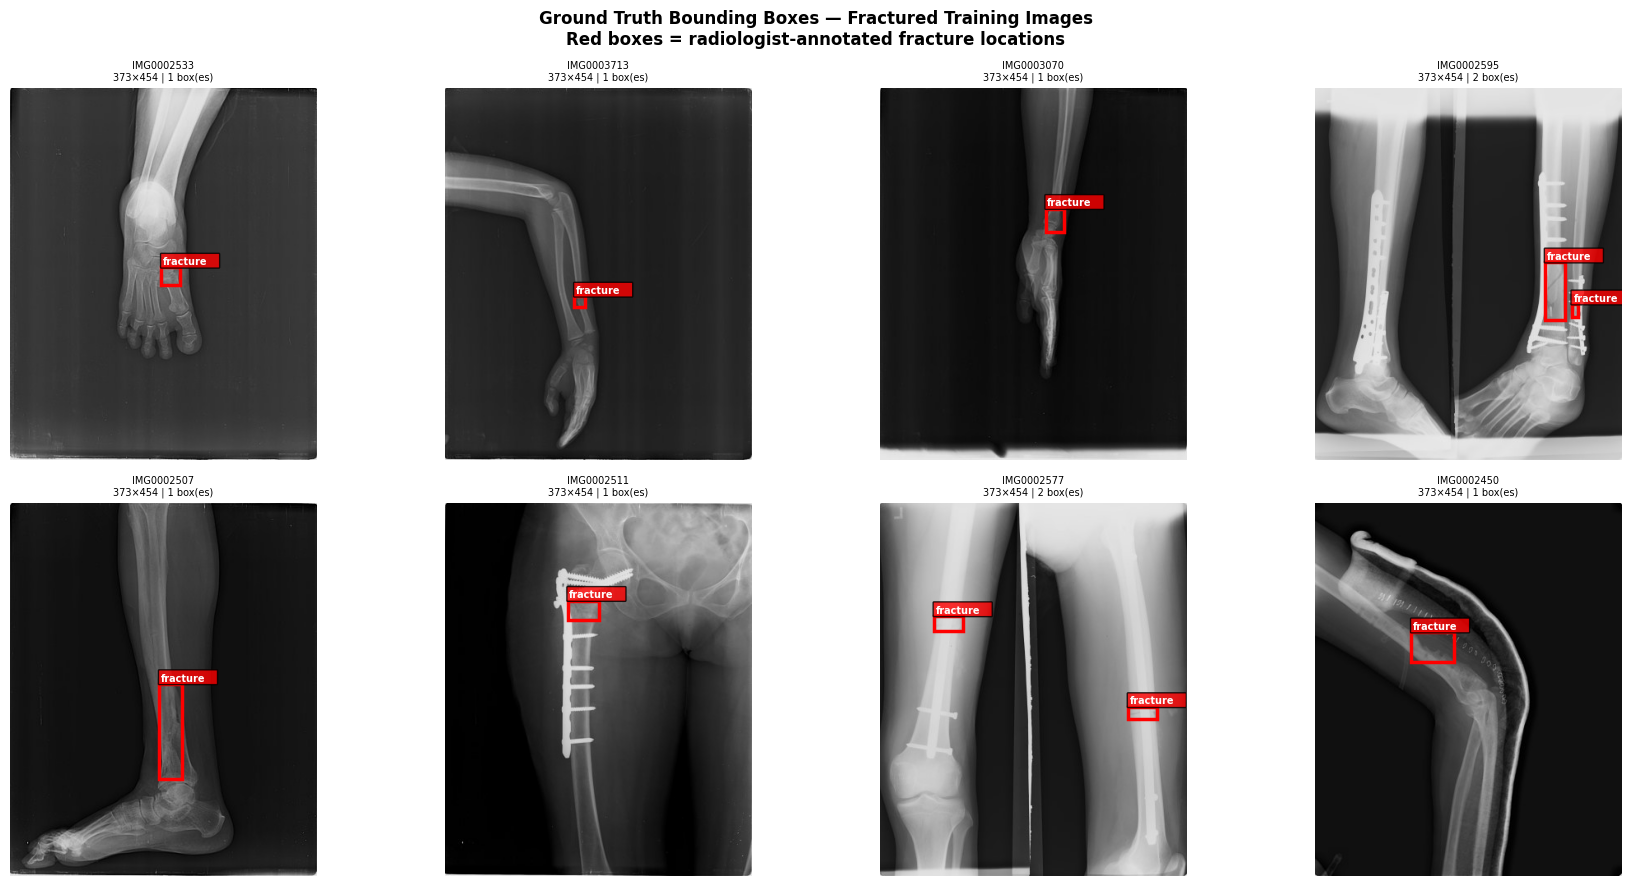

✅ Saved → ground_truth_boxes.png


In [ ]:
# Show 8 positive (fractured) training samples with bounding boxes
train_img_dir = DET_ROOT / 'train' / 'images'
train_lbl_dir = DET_ROOT / 'train' / 'labels'

# Only pick images that have bounding box annotations
pos_imgs = [img for img in train_img_dir.glob('*.jpg')
            if (train_lbl_dir / (img.stem+'.txt')).exists()
            and (train_lbl_dir / (img.stem+'.txt')).stat().st_size > 0]
random.shuffle(pos_imgs)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(pos_imgs): break
    img_path = pos_imgs[i]
    lbl_path = train_lbl_dir / (img_path.stem + '.txt')

    img  = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    with open(lbl_path) as f:
        boxes = 0
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, bw, bh = map(float, parts)
                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                ax.add_patch(patches.Rectangle(
                    (x1, y1), bw*W, bh*H,
                    linewidth=2.5, edgecolor='red', facecolor='none'
                ))
                ax.add_patch(patches.FancyBboxPatch(
                    (x1, y1-16), 70, 16,
                    boxstyle='round,pad=1', facecolor='red', alpha=0.8
                ))
                ax.text(x1+2, y1-4, 'fracture', color='white', fontsize=7, fontweight='bold')
                boxes += 1

    ax.set_title(f'{img_path.stem[:20]}\n{W}×{H} | {boxes} box(es)', fontsize=7)
    ax.axis('off')

plt.suptitle('Ground Truth Bounding Boxes — Fractured Training Images\n'
             'Red boxes = radiologist-annotated fracture locations',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(YOLO_OUT_DIR / 'ground_truth_boxes.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → ground_truth_boxes.png')

---
## ⚙️ Section 5 — Configure YOLOv8 Training

### Why YOLOv8s (small)?
- YOLOv8n (nano) is too small for medical imaging — misses thin fracture lines
- YOLOv8m/l (medium/large) overfits on 700 training images
- YOLOv8s is the sweet spot: 11M parameters, strong feature extraction, reasonable training time

### Augmentation handled by YOLOv8 internally
YOLOv8 has a built-in augmentation pipeline (mosaic, mixup, HSV jitter, flips).
We disable mosaic after 80% of epochs (standard practice) for final fine-tuning.

### data.yaml update
YOLOv8 needs absolute paths in data.yaml. We update it here.

In [ ]:
# Update data.yaml with absolute paths for Colab
yaml_content = f"""# FracAtlas Detection Dataset — YOLOv8
path: {DET_ROOT}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['fracture']
"""
with open(YOLO_YAML, 'w') as f:
    f.write(yaml_content)

print('✅ data.yaml updated with absolute paths')
print(yaml_content)

✅ data.yaml updated with absolute paths
# FracAtlas Detection Dataset — YOLOv8
path: /content/drive/MyDrive/CV_project_v4/detection_dataset
train: train/images
val: val/images
test: test/images

nc: 1
names: ['fracture']



---
## 🏋️ Section 6 — Train YOLOv8

Training uses COCO pretrained YOLOv8s weights as starting point.
The model adapts these general object detection features to fracture detection.

**Expected training time:** ~25–40 minutes on T4 GPU for 80 epochs

**What to watch:**
- `mAP50` — primary metric (IoU threshold 0.50): target > 0.55
- `mAP50-95` — stricter metric: target > 0.30
- `box_loss` — should decrease steadily
- `cls_loss` — classification confidence loss

Results are automatically saved to the project directory.

In [ ]:
# Load pretrained YOLOv8s
yolo_model = YOLO(YOLO_MODEL)
print(f'✅ YOLOv8s loaded from pretrained COCO weights')
print(f'   Parameters: {sum(p.numel() for p in yolo_model.model.parameters()):,}')

✅ YOLOv8s loaded from pretrained COCO weights
   Parameters: 25,902,640


In [ ]:
# Train YOLOv8
# All training logs and weights are saved automatically by ultralytics
results = yolo_model.train(
    data      = str(YOLO_YAML),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    device    = DEVICE,
    patience  = PATIENCE,
    seed      = SEED,
    project   = str(YOLO_OUT_DIR),
    name      = 'fracture_detection',
    save      = True,        # save best and last checkpoints
    save_period = 10,        # save checkpoint every 10 epochs
    exist_ok  = True,        # overwrite if already exists
    plots     = True,        # generate training plots
    # Augmentation settings
    hsv_h     = 0.0,         # no hue shift (X-rays are grayscale)
    hsv_s     = 0.0,         # no saturation shift
    hsv_v     = 0.5,         # slight brightness variation
    fliplr    = 0.5,         # horizontal flip
    flipud    = 0.2,         # vertical flip
    degrees   = 15.0,        # rotation
    translate = 0.1,        # translation
    scale     = 0.4,         # scale jitter
    mosaic    = 0.3,         # mosaic augmentation (reduced for medical)
    mixup     = 0.0,         # no mixup (can blur fracture lines)
    copy_paste= 0.0,    # no copy paste
    close_mosaic = 20,
)

print(f'\n✅ YOLOv8 training complete')
print(f'   Best weights: {YOLO_OUT_DIR}/fracture_detection/weights/best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CV_project_v4/detection_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=fracture_detection, nbs=64, nms=False, opset=None, optimize=False, opti

---
## 📊 Section 7 — Evaluate on Validation Set

**Metrics explained:**
- **mAP@50** — mean Average Precision at IoU=0.50. The box just needs to overlap
  the ground truth by 50%. Standard metric for medical detection.
- **mAP@50-95** — averaged over IoU thresholds 0.50 to 0.95. Much stricter.
- **Precision** — of all boxes the model drew, what fraction were correct?
- **Recall** — of all real fractures, what fraction did the model find?

In clinical settings, **high recall is more important than high precision** —
missing a fracture (false negative) is worse than a false alarm (false positive).

In [ ]:
# Load best checkpoint for evaluation
best_weights = YOLO_OUT_DIR / 'fracture_detection' / 'weights' / 'best.pt'
best_yolo    = YOLO(str(best_weights))

# Evaluate on validation set
val_metrics = best_yolo.val(
    data    = str(YOLO_YAML),
    split   = 'val',
    imgsz   = IMG_SIZE,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = DEVICE,
)

print('\n=== YOLO VALIDATION METRICS ===')
print(f'  mAP@50:     {val_metrics.box.map50:.4f}')
print(f'  mAP@50-95:  {val_metrics.box.map:.4f}')
print(f'  Precision:  {val_metrics.box.mp:.4f}')
print(f'  Recall:     {val_metrics.box.mr:.4f}')

---
## 🖼️ Section 8 — Visualize Detections on Validation Images

Shows 8 validation images with:
- **Red boxes** = ground truth (radiologist annotation)
- **Green boxes** = model prediction

This is the most impressive figure for your defense and report.

In [ ]:
val_img_dir = DET_ROOT / 'val' / 'images'
val_lbl_dir = DET_ROOT / 'val' / 'labels'

# Get images that have ground truth boxes
pos_val_imgs = [img for img in val_img_dir.glob('*.jpg')
                if (val_lbl_dir/(img.stem+'.txt')).exists()
                and (val_lbl_dir/(img.stem+'.txt')).stat().st_size > 0]
random.shuffle(pos_val_imgs)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(8, len(pos_val_imgs))]):
    img_path = pos_val_imgs[i]
    lbl_path = val_lbl_dir / (img_path.stem + '.txt')

    img  = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    # Ground truth boxes (red)
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, bw, bh = map(float, parts)
                x1 = (xc-bw/2)*W; y1 = (yc-bh/2)*H
                ax.add_patch(patches.Rectangle((x1,y1), bw*W, bh*H,
                             linewidth=2, edgecolor='red', facecolor='none', label='GT'))

    # Model predictions (green)
    preds = best_yolo.predict(str(img_path), conf=CONF_THRESH, iou=IOU_THRESH,
                               imgsz=IMG_SIZE)
    for det in preds[0].boxes:
        x1p, y1p, x2p, y2p = det.xyxy[0].cpu().numpy()
        conf_score = float(det.conf[0])
        ax.add_patch(patches.Rectangle((x1p, y1p), x2p-x1p, y2p-y1p,
                     linewidth=2, edgecolor='lime', facecolor='none'))
        ax.text(x1p, y1p-5, f'{conf_score:.2f}', color='lime',
                fontsize=8, fontweight='bold')

    ax.set_title(img_path.stem[:20], fontsize=7)
    ax.axis('off')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='red',  lw=2, label='Ground Truth'),
    Line2D([0],[0], color='lime', lw=2, label='YOLOv8 Prediction')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)

plt.suptitle('YOLOv8 Fracture Detection — Validation Set\n'
             'Red = Ground Truth  |  Green = Model Prediction  |  Number = Confidence',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig(YOLO_OUT_DIR/'detection_results.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → detection_results.png')

---
## 📉 Section 9 — Precision-Recall Curve & Training Curves

In [ ]:
# YOLOv8 saves training curves automatically — display them
results_dir = YOLO_OUT_DIR / 'fracture_detection'

auto_plots = [
    ('results.png',   'Training Metrics'),
    ('PR_curve.png',  'Precision-Recall Curve'),
    ('F1_curve.png',  'F1 Confidence Curve'),
    ('val_batch0_pred.jpg', 'Sample Val Batch Predictions'),
]

for fname, title in auto_plots:
    fpath = results_dir / fname
    if fpath.exists():
        img = Image.open(fpath)
        plt.figure(figsize=(14, 7))
        plt.imshow(img)
        plt.title(title, fontsize=13, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        # Copy to our outputs folder
        shutil.copy2(fpath, YOLO_OUT_DIR / fname)
        plt.show()
        print(f'✅ {fname}')
    else:
        print(f'⚠️  {fname} not found (may have different name)')

---
## 💾 Section 10 — Save Model Path to Config

In [ ]:
# Copy best weights to a consistent known path
YOLO_BEST_PATH = PROJECT_ROOT / 'best_yolov8_fracture.pt'
if best_weights.exists():
    shutil.copy2(best_weights, YOLO_BEST_PATH)
    print(f'✅ Best weights copied to: {YOLO_BEST_PATH}')

# Update config.json with YOLO model path
with open(CONFIG_PATH) as f:
    cfg = json.load(f)
cfg['yolo_best_weights'] = str(YOLO_BEST_PATH)
cfg['yolo_img_size']     = IMG_SIZE
cfg['yolo_conf_thresh']  = CONF_THRESH
cfg['yolo_iou_thresh']   = IOU_THRESH
with open(CONFIG_PATH, 'w') as f:
    json.dump(cfg, f, indent=2)
print(f'✅ dataset_config.json updated with YOLO paths')

---
## 🏁 Section 11 — Final Summary

In [ ]:
map50    = val_metrics.box.map50
map5095  = val_metrics.box.map
prec     = val_metrics.box.mp
rec      = val_metrics.box.mr

print('╔'+'═'*58+'╗')
print('║'+' YOLOv8 — Stage 2 Complete'.center(58)+'║')
print('╠'+'═'*58+'╣')
print(f'║  mAP@50:         {f"{map50:.4f}":<40}║')
print(f'║  mAP@50-95:      {f"{map5095:.4f}":<40}║')
print(f'║  Precision:      {f"{prec:.4f}":<40}║')
print(f'║  Recall:         {f"{rec:.4f}":<40}║')
print('╠'+'═'*58+'╣')
print(f'║  Model:    YOLOv8s (COCO pretrained → fracture)     ║')
print(f'║  Classes:  1 (fracture bounding box)                ║')
print(f'║  ImgSize:  {str(IMG_SIZE):<47}║')
print(f'║  Weights:  best_yolov8_fracture.pt                  ║')
print('╠'+'═'*58+'╣')
print(f'║  Clinical note: Recall={rec:.2%} means the model         ║')
print(f'║  detected that fraction of all real fractures.      ║')
print('╠'+'═'*58+'╣')
print('║  NEXT: Run Notebook E (Full Pipeline + Grad-CAM)    ║')
print('╚'+'═'*58+'╝')